# Analyze Autoregressive Rollout Error

This notebook loads the per-timestep error data generated by `evaluate.py` and uses the reusable plotting function from `mhd_surrogate_core` to visualize the model's long-term stability.

### 1. Setup and Imports

In [3]:
from pathlib import Path

# Make sure your packages are installed in editable mode
from mhd_surrogate_core.plot import plot_rollout_error

### 2. Specify Error File Path and Plot

**Action Required:** Change the `error_file_path` variable below to point to the specific `rollout_error.npz` file you want to analyze. This file is generated by the `evaluate.py` script.

2025-07-05 10:55:01,190 - INFO - Loading rollout error from ../experiments/study_1_param_sweep/output/test_run_ep256_clip25/eval/rollout_error_train_val.npz...


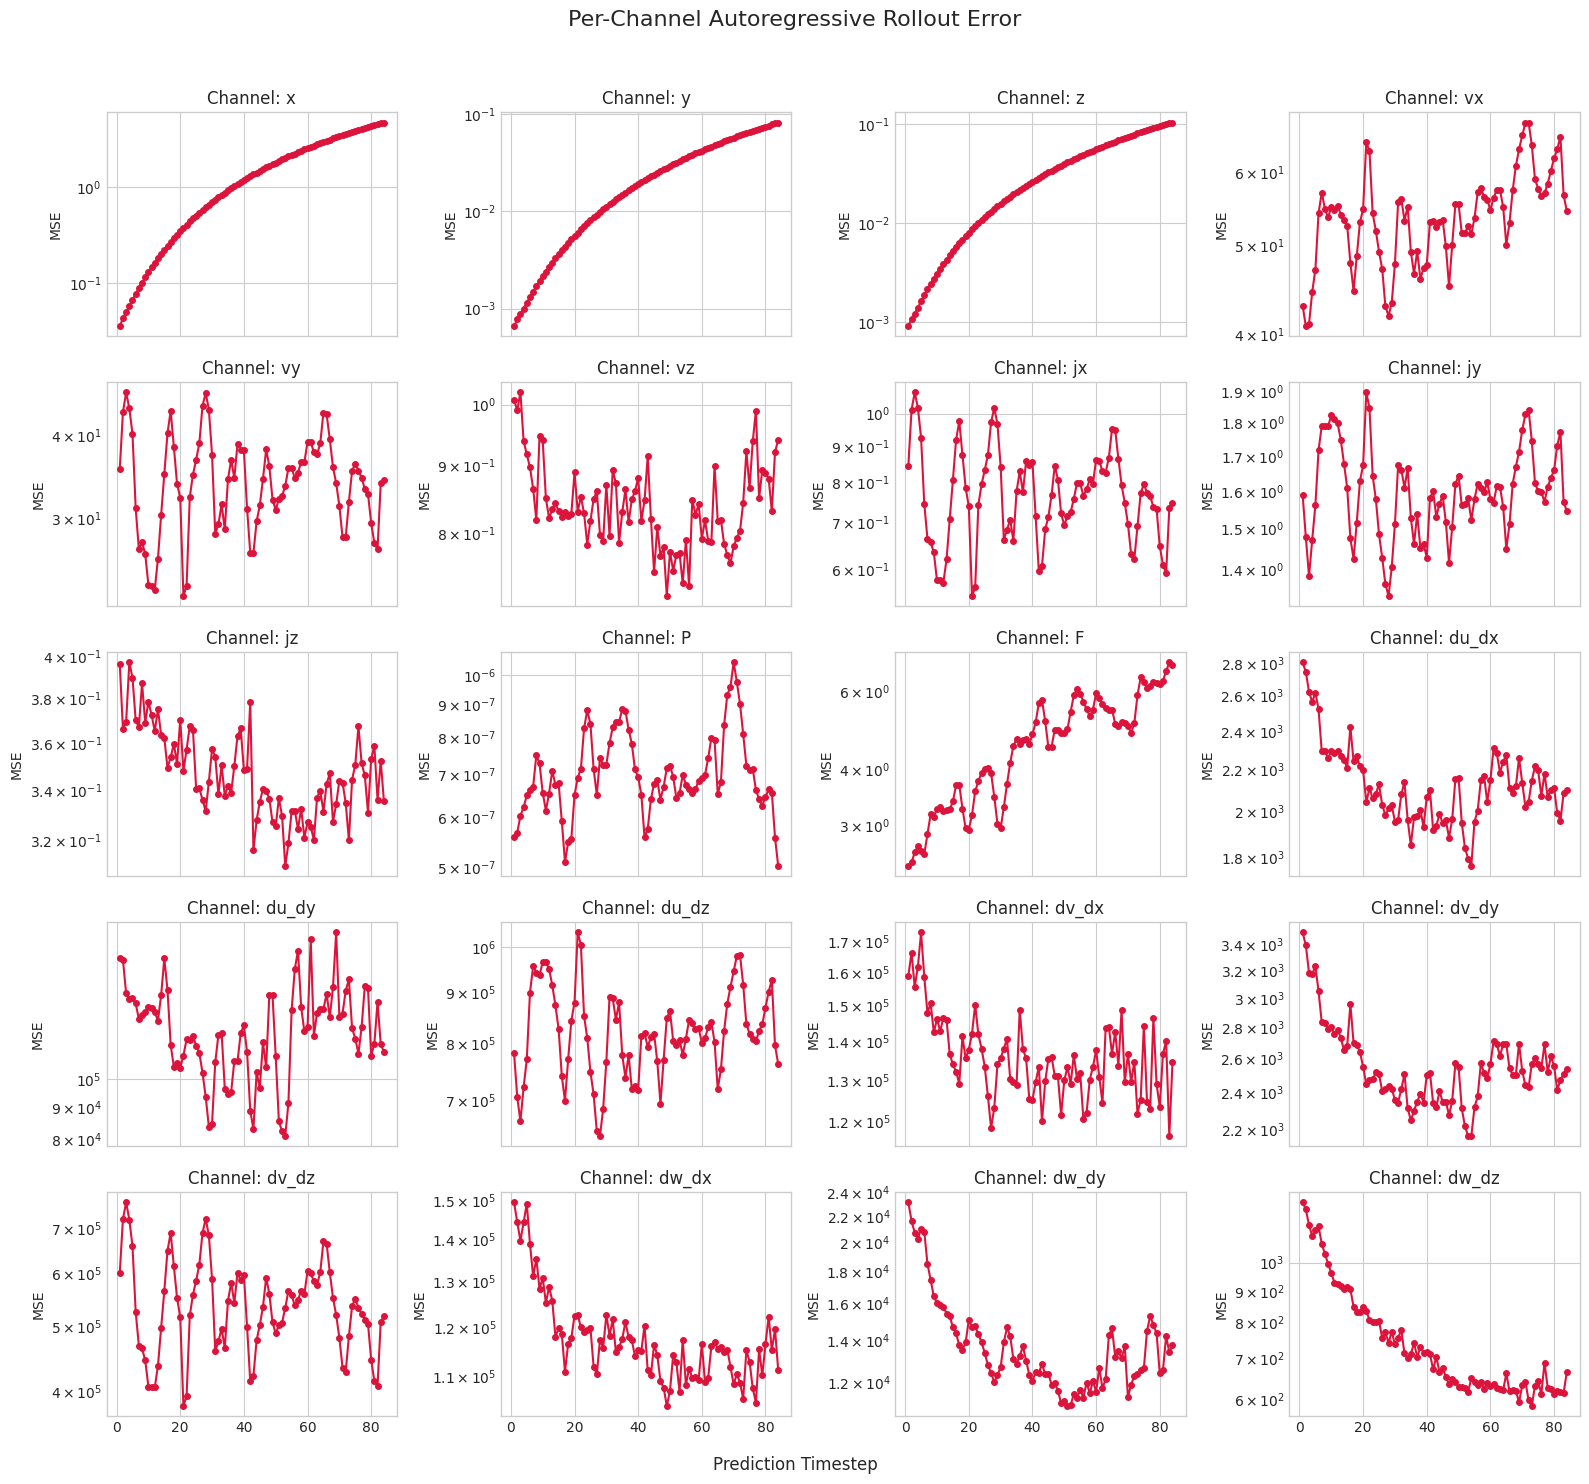

In [4]:
# Example path - update this to your specific run's output.
# This path matches the structure created by the run_sweep.sh script.
error_file_path = Path("../experiments/study_1_param_sweep/output/test_run_ep256_clip25/eval/rollout_error_train_val.npz")

# Call the plotting function
if error_file_path.exists():
    plot_rollout_error(error_file_path)
else:
    print(f"ERROR: Error file not found at {error_file_path}")
    print("Please run evaluate.py first and/or update the path.")

### Analysis

This plot is one of the most important for evaluating a surrogate model:

- **A Stable Model:** The error should start low and remain low and flat for the entire duration of the rollout. This indicates the learned dynamics are stable and do not accumulate error over time.
- **An Unstable Model:** The error will start low but then grow rapidly, often exponentially. This indicates that small one-step prediction errors are being amplified at each subsequent step, leading to a divergent, unphysical trajectory. This is a classic failure mode for Koopman-based models, often addressed by techniques like eigenvalue regularization.